In [ ]:
ADVANCED MULTIMODAL CNN MODEL 1

In [1]:
import os
import cv2
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, concatenate
from tensorflow.keras.utils import to_categorical

In [2]:
df = pd.read_excel("patients.xlsx")
df.columns = df.columns.str.strip()

df['Diagnosis'] = df['Diagnosis'].fillna('normal')
df['Diagnosis'] = df['Diagnosis'].apply(
    lambda x: 'normal' if str(x).lower() == 'normal' else 'abnormal'
)

df['SL'] = df['SL'].astype(int)

# FIX AGE
def convert_age(age):
    try:
        if isinstance(age, str):
            if '-' in age:
                low, high = age.split('-')
                return (float(low) + float(high)) / 2
            elif '+' in age:
                return float(age.replace('+',''))
            else:
                return float(age)
        return float(age)
    except:
        return np.nan

df['Age'] = df['Age'].apply(convert_age)
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [3]:
scaler = StandardScaler()
X_tab = scaler.fit_transform(df[['Age']].values)

le = LabelEncoder()
y = le.fit_transform(df['Diagnosis'])
y = to_categorical(y)

In [4]:
image_dir = "Augmented Images"
IMG_SIZE = 224

X_img, X_tab_final, y_final = [], [], []

for i, row in df.iterrows():

    patient_id = "P" + str(row['SL'])
    folder_path = os.path.join(image_dir, patient_id)

    if not os.path.exists(folder_path):
        continue

    for img in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img)
        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0

        X_img.append(image)
        X_tab_final.append(X_tab[i])
        y_final.append(y[i])

X_img = np.array(X_img)
X_tab_final = np.array(X_tab_final)
y_final = np.array(y_final)

In [5]:
X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_img, X_tab_final, y_final, test_size=0.2, random_state=42
)

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

In [7]:
tab_input = Input(shape=(X_tab_train.shape[1],))

t = Dense(64, activation='relu')(tab_input)
t = BatchNormalization()(t)
t = Dense(32, activation='relu')(t)

In [8]:
combined = concatenate([x, t])

z = Dense(128, activation='relu')(combined)
z = Dropout(0.5)(z)

output = Dense(y_train.shape[1], activation='softmax')(z)

model = Model(inputs=[base_model.input, tab_input], outputs=output)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    [X_img_train, X_tab_train],
    y_train,
    epochs=25,
    batch_size=8,
    validation_data=([X_img_test, X_tab_test], y_test)
)

Epoch 1/25
564/564 ━━━━━━━━━━━━━━━━━━━━ 123s 194ms/step - accuracy: 0.8005 - loss: 0.5198 - val_accuracy: 0.8394 - val_loss: 0.3663
Epoch 2/25
564/564 ━━━━━━━━━━━━━━━━━━━━ 93s 165ms/step - accuracy: 0.8324 - loss: 0.3833 - val_accuracy: 0.8740 - val_loss: 0.2946
Epoch 3/25
564/564 ━━━━━━━━━━━━━━━━━━━━ 95s 168ms/step - accuracy: 0.8597 - loss: 0.3363 - val_accuracy: 0.8953 - val_loss: 0.2521
Epoch 4/25
564/564 ━━━━━━━━━━━━━━━━━━━━ 97s 172ms/step - accuracy: 0.8731 - loss: 0.3037 - val_accuracy: 0.9157 - val_loss: 0.2295
Epoch 5/25
564/564 ━━━━━━━━━━━━━━━━━━━━ 100s 178ms/step - accuracy: 0.8895 - loss: 0.2598 - val_accuracy: 0.9317 - val_loss: 0.1779
Epoch 6/25
564/564 ━━━━━━━━━━━━━━━━━━━━ 98s 174ms/step - accuracy: 0.9070 - loss: 0.2467 - val_accuracy: 0.9397 - val_loss: 0.1645
Epoch 7/25
564/564 ━━━━━━━━━━━━━━━━━━━━ 100s 177ms/step - accuracy: 0.9199 - loss: 0.2054 - val_accuracy: 0.9264 - val_loss: 0.1657
Epoch 8/25
564/564 ━━━━━━━━━━━━━━━━━━━━ 99s 176ms/step - accuracy: 0.9221 - loss

In [11]:
loss, acc = model.evaluate([X_img_test, X_tab_test], y_test)
print("Advanced Multimodal Accuracy =", acc)

36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 421ms/step - accuracy: 0.9734 - loss: 0.0797
Advanced Multimodal Accuracy = 0.9733806848526001


In [ ]:
CAM CNN MODEL  MODEL 2

In [1]:
import os
import cv2
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, GlobalAveragePooling2D,
                                     BatchNormalization, concatenate, Multiply)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_excel("patients.xlsx")
df.columns = df.columns.str.strip()

df['Diagnosis'] = df['Diagnosis'].fillna('normal')
df['Diagnosis'] = df['Diagnosis'].apply(
    lambda x: 'normal' if str(x).lower() == 'normal' else 'abnormal'
)

df['SL'] = df['SL'].astype(int)

def convert_age(age):
    try:
        if isinstance(age, str):
            if '-' in age:
                low, high = age.split('-')
                return (float(low) + float(high)) / 2
            elif '+' in age:
                return float(age.replace('+',''))
            else:
                return float(age)
        return float(age)
    except:
        return np.nan

df['Age'] = df['Age'].apply(convert_age)
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [3]:
scaler = StandardScaler()
X_tab = scaler.fit_transform(df[['Age']].values)

le = LabelEncoder()
y = le.fit_transform(df['Diagnosis'])
y = to_categorical(y)

In [4]:
image_dir = "Augmented Images"
IMG_SIZE = 256

X_img, X_tab_final, y_final = [], [], []

for i, row in df.iterrows():

    patient_id = "P" + str(row['SL'])
    folder_path = os.path.join(image_dir, patient_id)

    if not os.path.exists(folder_path):
        continue

    for img in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img)
        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0

        X_img.append(image)
        X_tab_final.append(X_tab[i])
        y_final.append(y[i])

X_img = np.array(X_img)
X_tab_final = np.array(X_tab_final)
y_final = np.array(y_final)

print("Total samples:", len(X_img))

Total samples: 5633


In [5]:
X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_img, X_tab_final, y_final, test_size=0.05, random_state=42
)

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(256,256,3)
)

for layer in base_model.layers:
    layer.trainable = False

# 🔥 Unfreeze more layers
for layer in base_model.layers[-80:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)

C:\Users\ANUSHREE\AppData\Local\Temp\ipykernel_9484\4145110398.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [7]:
tab_input = Input(shape=(X_tab_train.shape[1],))

t = Dense(64, activation='relu')(tab_input)
t = BatchNormalization()(t)
t = Dense(32, activation='relu')(t)

In [8]:
img_conf = Dense(1, activation='sigmoid')(x)
tab_conf = Dense(1, activation='sigmoid')(t)

x_weighted = Multiply()([x, img_conf])
t_weighted = Multiply()([t, tab_conf])

In [9]:
combined = concatenate([x_weighted, t_weighted])

z = Dense(256, activation='relu')(combined)
z = Dropout(0.5)(z)
z = Dense(128, activation='relu')(z)

output = Dense(y_train.shape[1], activation='softmax')(z)

model = Model(inputs=[base_model.input, tab_input], outputs=output)

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    [X_img_train, X_tab_train],
    y_train,
    epochs=60,
    batch_size=8,
    validation_data=([X_img_test, X_tab_test], y_test),
    callbacks=[early_stop]
)

Epoch 1/60
669/669 ━━━━━━━━━━━━━━━━━━━━ 292s 401ms/step - accuracy: 0.7987 - loss: 0.4281 - val_accuracy: 0.8404 - val_loss: 0.3387
Epoch 2/60
669/669 ━━━━━━━━━━━━━━━━━━━━ 314s 390ms/step - accuracy: 0.8757 - loss: 0.2472 - val_accuracy: 0.8688 - val_loss: 0.6261
Epoch 3/60
669/669 ━━━━━━━━━━━━━━━━━━━━ 237s 354ms/step - accuracy: 0.9495 - loss: 0.1475 - val_accuracy: 0.9184 - val_loss: 0.3552
Epoch 4/60
669/669 ━━━━━━━━━━━━━━━━━━━━ 266s 359ms/step - accuracy: 0.9736 - loss: 0.0852 - val_accuracy: 0.9220 - val_loss: 0.3594
Epoch 5/60
669/669 ━━━━━━━━━━━━━━━━━━━━ 300s 416ms/step - accuracy: 0.9750 - loss: 0.0800 - val_accuracy: 0.9716 - val_loss: 0.1908
Epoch 6/60
669/669 ━━━━━━━━━━━━━━━━━━━━ 246s 368ms/step - accuracy: 0.9843 - loss: 0.0495 - val_accuracy: 0.9681 - val_loss: 0.2252
Epoch 7/60
669/669 ━━━━━━━━━━━━━━━━━━━━ 247s 369ms/step - accuracy: 0.9821 - loss: 0.0536 - val_accuracy: 0.9752 - val_loss: 0.1048
Epoch 8/60
669/669 ━━━━━━━━━━━━━━━━━━━━ 262s 368ms/step - accuracy: 0.9884 -

In [12]:
loss, acc = model.evaluate([X_img_test, X_tab_test], y_test)
print("FINAL BOOSTED ACCURACY =", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9894 - loss: 0.0463   
FINAL BOOSTED ACCURACY = 0.9893617033958435


In [ ]:
ACCURACY AND LOSS GRAPH

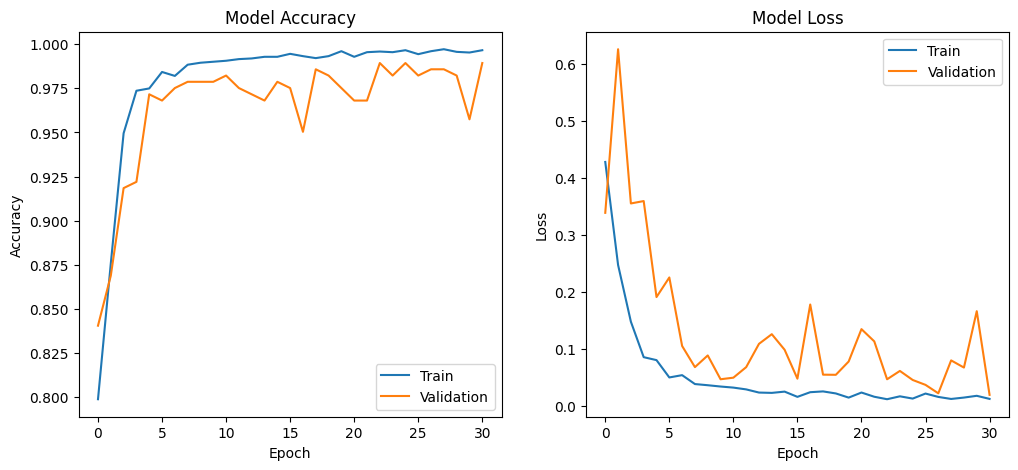

In [14]:


import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
CONFUSION MATRIX 

In [18]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [20]:
y_pred = model.predict([X_img_test, X_tab_test])

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 919ms/step


In [21]:
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

[[236   1]
 [  2  43]]


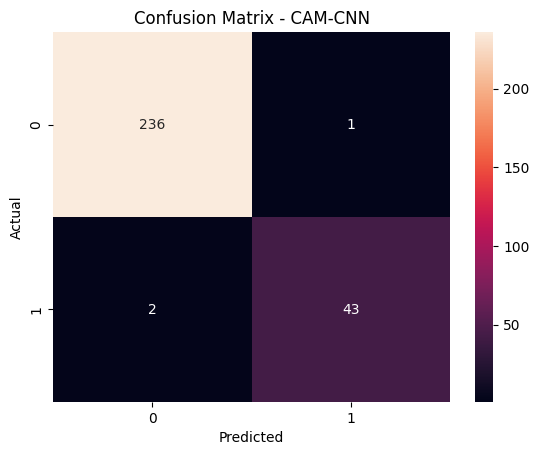

In [22]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix - CAM-CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       237
           1       0.98      0.96      0.97        45

    accuracy                           0.99       282
   macro avg       0.98      0.98      0.98       282
weighted avg       0.99      0.99      0.99       282



In [ ]:
ROC CURVE

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

In [28]:
y_pred_prob = model.predict([X_img_test, X_tab_test])

# take probability of class 1
y_pred_prob = y_pred_prob[:, 1]

y_true = np.argmax(y_test, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 563ms/step


In [29]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

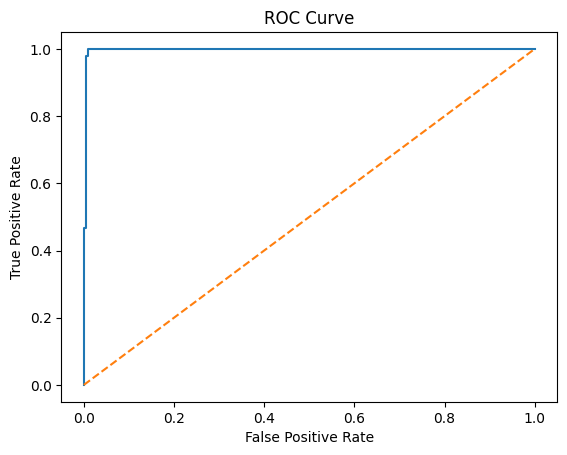

In [30]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()